In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 06. SVM とカーネル法 — マージン最大化と「曲げる」技

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- **最大マージン分類器** が「境界とデータの最短距離」を最大化すること、**サポートベクトル** とは何か
- **ソフトマージン** と罰則 **C**(誤分類の許容度)
- **カーネルトリック** — 高次元へ写像せずに非線形境界を引く仕組み
- 線形 / 多項式 / **RBF** カーネルの違いと、RBF の **gamma**(局所性)
- SVM では **特徴のスケーリングが必須** なこと

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, widgets
from sklearn.svm import SVC

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 最大マージン分類器とサポートベクトル

線形分離できるとき、無数に引ける境界の中で SVM は **マージン**(境界から最も近い点までの距離)を
最大にする境界を選びます。境界を支える最も近い点が **サポートベクトル** で、これだけが解を決めます。

$$
\min_{w,b}\ \tfrac12\lVert w\rVert^2 \quad \text{s.t.}\quad y_i(w^\top x_i + b)\ge 1
$$

$\lVert w\rVert$ を小さくするほどマージン $2/\lVert w\rVert$ は広がります。

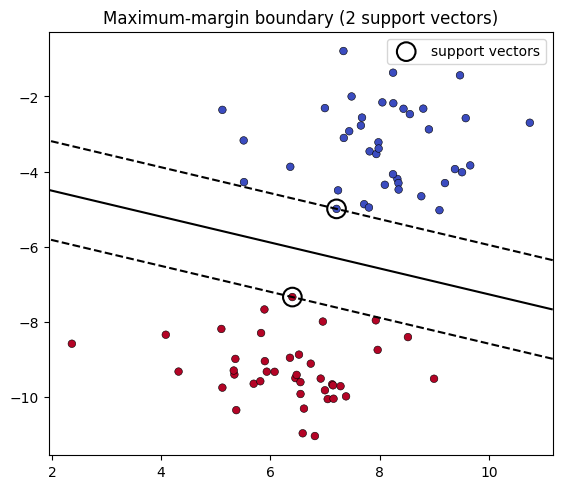

In [3]:
Xb, yb = datasets.make_blobs_dataset(n=80, centers=2, cluster_std=1.1, seed=6)
clf = SVC(kernel="linear", C=1000).fit(Xb, yb)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="coolwarm", s=30, edgecolors="k", linewidths=0.4)
xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), 200), np.linspace(*ax.get_ylim(), 200))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
sv = clf.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=180, facecolors="none", edgecolors="k", linewidths=1.5, label="support vectors")
ax.set_title(f"Maximum-margin boundary ({len(sv)} support vectors)"); ax.legend(); plt.show()

## 2. ソフトマージンと C

現実のデータは重なります。**ソフトマージン** は誤分類をある程度許し、その量を **C** で調整します。

- **C 小** → 罰則が弱い → マージン広い・誤分類を許容(正則化強・単純)
- **C 大** → 罰則が強い → マージン狭い・誤分類を嫌う(過学習寄り)

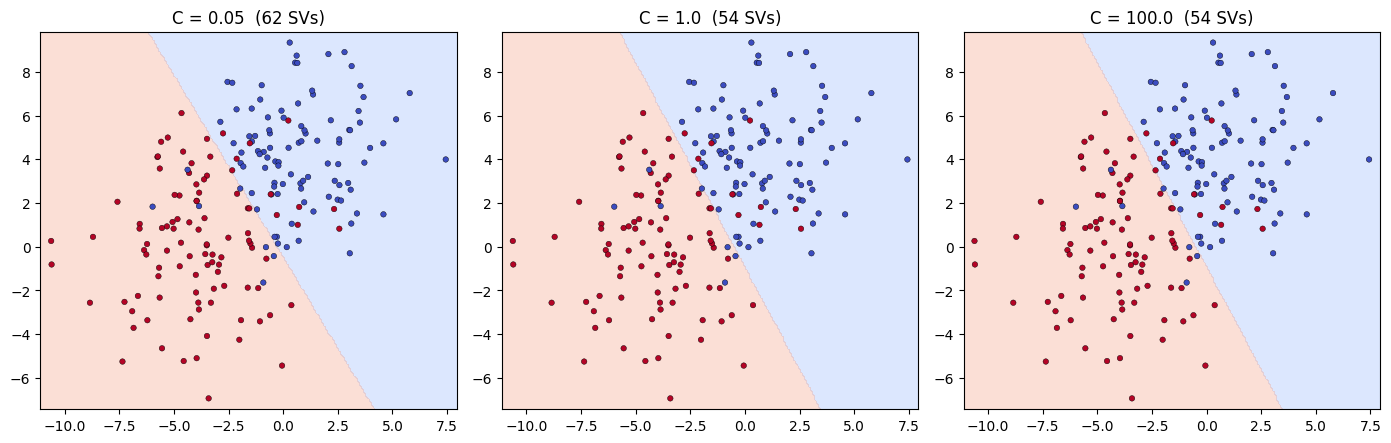

In [4]:
Xo, yo = datasets.make_blobs_dataset(n=200, centers=2, cluster_std=2.4, seed=3)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, C in zip(axes, [0.05, 1.0, 100.0]):
    clf = SVC(kernel="linear", C=C).fit(Xo, yo)
    plotting.plot_decision_boundary(clf.predict, Xo, yo, ax=ax, steps=200,
                                    title=f"C = {C}  ({len(clf.support_vectors_)} SVs)")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. カーネルトリック — 写像せずに曲げる

同心円データは直線では分けられません。しかし $(x_1, x_2)\mapsto x_1^2 + x_2^2$(原点からの距離²)を考えると、
内側の円は小さく外側は大きく、**1 本のしきい値で分離可能** になります。

カーネルは、この「高次元での内積(類似度)」を **明示的に写像せずに** 計算する仕組みです。
RBF カーネル $k(x,x') = \exp(-\gamma\lVert x-x'\rVert^2)$ は「近い点ほど似ている」を表します。

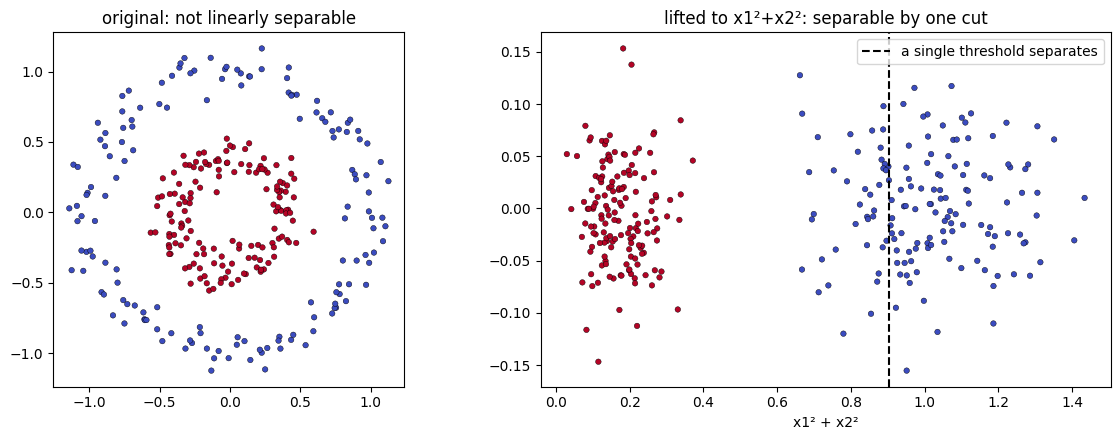

In [5]:
Xc, yc = datasets.make_circles_dataset(n=300, noise=0.08, factor=0.4, seed=0)
r2 = (Xc**2).sum(axis=1)   # the lifting feature x1^2 + x2^2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", s=16, edgecolors="k", linewidths=0.3)
axes[0].set_title("original: not linearly separable"); axes[0].set_aspect("equal")
axes[1].scatter(r2, 0.05 * np.random.default_rng(0).standard_normal(len(r2)), c=yc, cmap="coolwarm", s=16,
                edgecolors="k", linewidths=0.3)
axes[1].axvline(np.sort(r2)[len(r2)//2 + 40], color="k", ls="--", label="a single threshold separates")
axes[1].set_title("lifted to x1²+x2²: separable by one cut"); axes[1].set_xlabel("x1² + x2²"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. カーネルの比較

同じ moons データに線形 / 多項式 / RBF カーネルを当てます。線形は曲げられず、RBF は柔軟に曲がります。

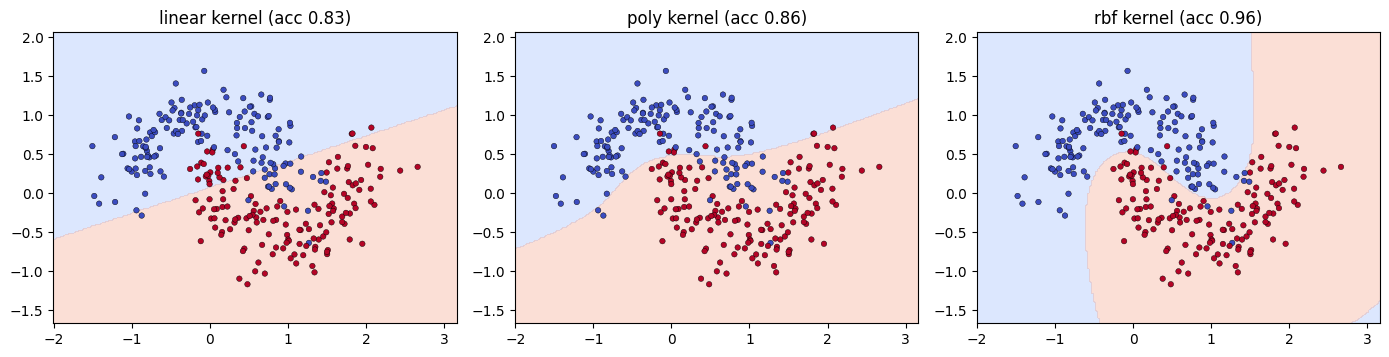

In [6]:
Xm, ym = datasets.make_moons_dataset(n=300, noise=0.25, seed=0)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, kernel in zip(axes, ["linear", "poly", "rbf"]):
    clf = SVC(kernel=kernel, C=1.0, gamma="scale", degree=3).fit(Xm, ym)
    plotting.plot_decision_boundary(clf.predict, Xm, ym, ax=ax, steps=200,
                                    title=f"{kernel} kernel (acc {clf.score(Xm, ym):.2f})")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 5. RBF の gamma — 局所性のつまみ

$\gamma$ は「各点の影響が届く範囲」。

- **gamma 小** → 影響が広い → なめらか(単純)
- **gamma 大** → 影響が狭い → 各点の周りだけ反応 → ギザギザ(過学習)

下のスライダー(静的 HTML 可)で gamma を上げると、境界が点に張り付いていきます。

In [7]:
Xm, ym = datasets.make_moons_dataset(n=250, noise=0.25, seed=0)
pad = 0.5
xs = np.linspace(Xm[:, 0].min() - pad, Xm[:, 0].max() + pad, 120)
ys = np.linspace(Xm[:, 1].min() - pad, Xm[:, 1].max() + pad, 120)
xx, yy = np.meshgrid(xs, ys)
grid = np.c_[xx.ravel(), yy.ravel()]
gammas = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]

def traces(g):
    clf = SVC(kernel="rbf", C=1.0, gamma=g).fit(Xm, ym)
    Z = clf.decision_function(grid).reshape(xx.shape)
    return [
        go.Heatmap(x=xs, y=ys, z=Z, colorscale="RdBu", zmid=0, showscale=False, opacity=0.8),
        go.Scatter(x=list(Xm[:, 0]), y=list(Xm[:, 1]), mode="markers",
                   marker={"color": list(map(int, ym)), "colorscale": "RdBu",
                           "line": {"color": "black", "width": 0.5}, "size": 7}, showlegend=False),
    ]

frames = [go.Frame(name=f"{g:g}", data=traces(g), layout={"title": f"RBF gamma = {g:g}"}) for g in gammas]
fig = go.Figure(data=traces(gammas[2]), frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "gamma = "}}],
                  title="RBF gamma = 1", width=620, height=560,
                  xaxis={"title": "x1"}, yaxis={"title": "x2", "scaleanchor": "x"},
                  margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

### インタラクティブ(JupyterLab のみ): C と gamma を同時に

2 つのスライダーで C と gamma を動かし、両者のバランスで境界がどう変わるか確かめます。

In [8]:
widgets.svm_explorer(Xm, ym)

interactive(children=(FloatSlider(value=0.0, description='log10 C', max=3.0, min=-2.0, step=0.5), FloatSlider(…

<function ml_textbook.widgets.svm_explorer.<locals>.draw(log_C, log_gamma)>

## 6. 実務上の注意 — 必ずスケーリング

SVM は距離(内積)で動くので、特徴のスケールが違うと大きい特徴に支配されます。**標準化が必須**。

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

bc = datasets.load_breast_cancer_dataset()
raw = cross_val_score(SVC(), bc.data, bc.target, cv=5).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), SVC()), bc.data, bc.target, cv=5).mean()
print(f"SVC raw     CV acc = {raw:.3f}")
print(f"SVC + scale CV acc = {scaled:.3f}   <- scaling is not optional for SVM")

SVC raw     CV acc = 0.912
SVC + scale CV acc = 0.974   <- scaling is not optional for SVM


## 7. まとめ

- SVM は **マージン最大化**。境界を支える **サポートベクトル** だけが解を決める。
- **C** は誤分類の許容度(小=単純、大=過学習寄り)。
- **カーネル** は高次元へ写像せず非線形境界を引く技。RBF が汎用的。
- RBF の **gamma** は局所性(小=なめらか、大=過学習)。C と gamma は交差検証で同時に選ぶ。
- **スケーリング必須**。確率が必要なら `probability=True` か `CalibratedClassifierCV`。

## 8. Exercises

1. マージン図で `C` を 1000 → 1 にすると、サポートベクトルの数はどう変わるか。
2. gamma スライダーで、訓練精度は上がるのに見た目が過学習に見える gamma を特定せよ。
3. moons の `noise` を 0.4 にして、線形/poly/RBF の精度差がどう開くか比べよ。
4. `make_circles_dataset` に linear SVM と RBF SVM を当て、精度を比較せよ。
5. (発展)`GridSearchCV` で C と gamma を同時に最適化し、単発設定より良くなるか確かめよ(10 章の予習)。

## 9. Common Mistakes

- **スケーリングしない。** SVM では致命的。必ず標準化。
- **C と gamma を別々に調整。** 相互作用するので一緒に探索する。
- **大データに RBF-SVM。** 学習が $O(n^2)$ 近く重い。大規模なら線形 SVM や勾配ブースティングを検討。
- **SVM の出力をそのまま確率扱い。** 既定では確率ではない。較正が必要。

## 10. Advanced Notes

**双対表現とカーネル。** SVM の解は $w = \sum_i \alpha_i y_i x_i$ とサポートベクトルの線形結合で書け、
予測は内積 $x^\top x_i$ にしか依存しない。この内積を $k(x, x_i)$ に置き換えるだけで非線形化できる
— これが **カーネルトリック**。RBF は実質的に無限次元の特徴空間に対応する。